In [ ]:
import pandas as pd
import re
import nltk

import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud




In [ ]:
#required nltk files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicom')
nltk.download('punkt_tab')
nltk.download('vader_lexicon')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Error loading vader_lexicom: Package 'vader_lexicom' not
[nltk_data]     found in index
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [20]:
df = pd.read_csv("abc.csv", engine="python")

In [21]:
df.head()

,review
0,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...
2,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is..."


In [22]:
df.columns

Index(['review'], dtype='object')

In [24]:
df.isna().sum()

,0
review,0


In [25]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', '', text)      # Remove HTML tags
    text = re.sub(r'http\S+', '', text)    # Remove URLs
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_review"] = df["review"].apply(clean_text)

In [26]:
print(df['clean_review'])

0        One of the other reviewers has mentioned that ...
1        A wonderful little production. The filming tec...
2        I thought this was a wonderful way to spend ti...
3        Basically there's a family where a little boy ...
4        Petter Mattei's "Love in the Time of Money" is...
                               ...                        
49995    I thought this movie did a down right good job...
49996    Bad plot, bad dialogue, bad acting, idiotic di...
49997    I am a Catholic taught in parochial elementary...
49998    I'm going to have to disagree with the previou...
49999    No one expects the Star Trek movies to be high...
Name: clean_review, Length: 50000, dtype: object


In [27]:
stop_words=set(stopwords.words('english'))
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [28]:
sia=SentimentIntensityAnalyzer()
def analyze_sentiment(review):
    score=sia.polarity_scores(review)
    compound=score['compound']
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'
df['Sentiment'] = df['clean_review'].apply(analyze_sentiment)

print("\n Sentiment Analysis")
print(df[['review', 'Sentiment']])


 Sentiment Analysis
                                                  review Sentiment
0      One of the other reviewers has mentioned that ...  Negative
1      A wonderful little production. <br /><br />The...  Positive
2      I thought this was a wonderful way to spend ti...  Positive
3      Basically there's a family where a little boy ...  Negative
4      Petter Mattei's "Love in the Time of Money" is...  Positive
...                                                  ...       ...
49995  I thought this movie did a down right good job...  Positive
49996  Bad plot, bad dialogue, bad acting, idiotic di...  Negative
49997  I am a Catholic taught in parochial elementary...  Negative
49998  I'm going to have to disagree with the previou...  Negative
49999  No one expects the Star Trek movies to be high...  Positive

[50000 rows x 2 columns]


In [29]:
print("\nSentiment Distribution")
print(df['Sentiment'].value_counts())


Sentiment Distribution
Sentiment
Positive    32791
Negative    16868
Neutral       341
Name: count, dtype: int64


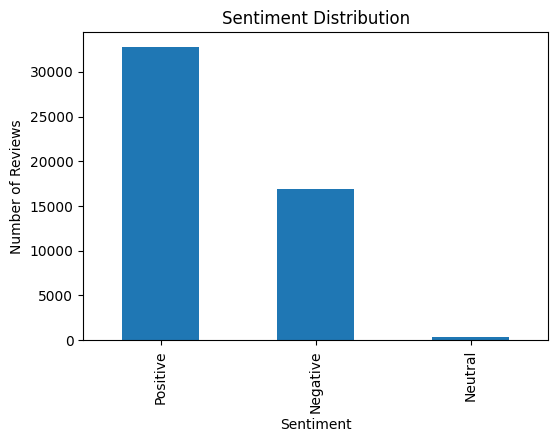

In [30]:
plt.figure(figsize=(6,4))

df['Sentiment'].value_counts().plot(kind='bar')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

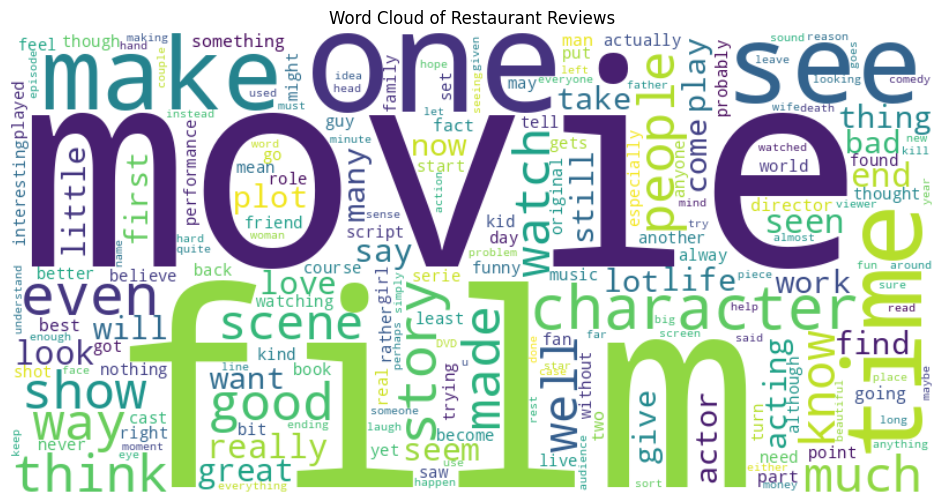

In [32]:
all_reviews = " ".join(df['clean_review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Restaurant Reviews')
plt.show()